In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline # 스케일링 + 모델을 한 번에 연결하는 파이프라인 기능을 위함
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier # 여러 모델을 결합하는 Voting 앙상블 모델을 사용하기 위함

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    classification_report
)

In [19]:
# 데이터 로드
iris = load_iris() # 아이리스 데이터를 읽어옴
X = iris.data # x데이터를 정의함
y = iris.target # y데이터를 정의함
class_names = iris.target_names # 0,1,2 에 대해 문자값을 사용가능하게함
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=45,
    stratify=y, # 계층적 표현
)

In [14]:
# 개별 모델 정의 (SVM, KNN, RandomForest)
# SVM
svm_clf = make_pipeline( # make_pipeline: 입력값의 StandardScaler 적용과 함께 모델을 파이프라인으로 묶어 사용
    StandardScaler(),
    SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
)

# KNN (트리모델)
knn_clf = make_pipeline( # clf: 클래시피케이션(classification)의 약자이다.
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None, # 트리의 개수를 제한하지 않음
    random_state=42
)

# 앙상블 모델 정의
# 3개의 모델을 soft voting 방식으로 결합한 votingclassifier 정의
voting_clf = VotingClassifier(
    estimators=[('svm',svm_clf), ('knn', knn_clf), ('rf', rf_clf)],
    voting = 'soft', # 각 모델의 예측 확률값을 평균내어 최종 예측을 만듦
    weights=[1,1,2], # 랜덤 포레스트 모델의 가중치 높임 (예측 결과 비중을 높임)
)

In [15]:
# 모델 학습
svm_clf.fit(X_train, y_train)
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'


In [17]:
# 모델 평가 및 정확도 출력
y_pred = voting_clf.predict(X_test) # x_test 데이터를 넣고 예측
accuarcy = accuracy_score(y_test, y_pred)

print("==== voting classification ====")
print("accuracy: ", round(accuarcy, 4))

==== voting classification ====
accuracy:  0.9


<Axes: >

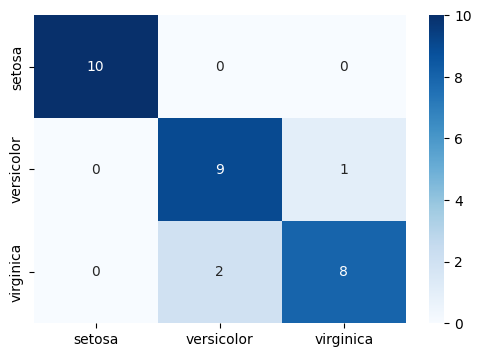

In [22]:
# confusion matrix 시각화
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm, annot=True, cmap='Blues', fmt='d',
    xticklabels=class_names, yticklabels=class_names
)


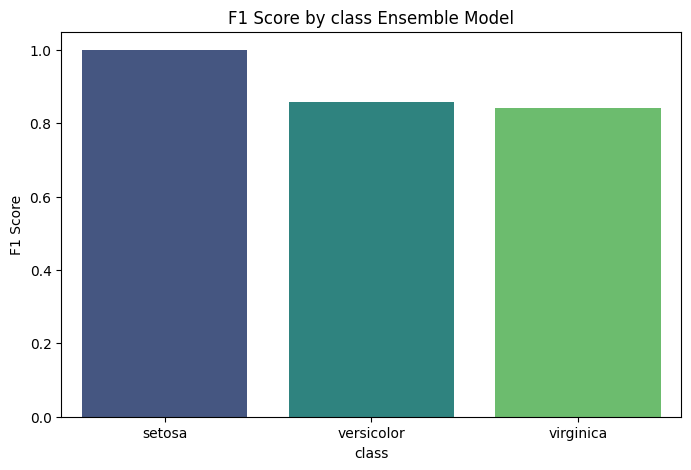

In [25]:
# classification
report = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True, # dict 형태로 받아와서 dataframe으로 시각화 출력
)

# f1-score 확인 (class 별 f1-score 값만 리스트로 받아옴)
f1_score = [report[class_name]['f1-score'] for class_name in class_names]
df_f1 = pd.DataFrame({'class': class_names, 'f1': f1_score})

plt.figure(figsize=(8,5))
sns.barplot(data=df_f1, x='class', y='f1', hue='class', palette='viridis', legend=False)

plt.title("F1 Score by class Ensemble Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05) # 그래프에서 출력할 y값의 범위 지정 (0~1.05 사이의 그래프 값만 뽑음)

plt.show()

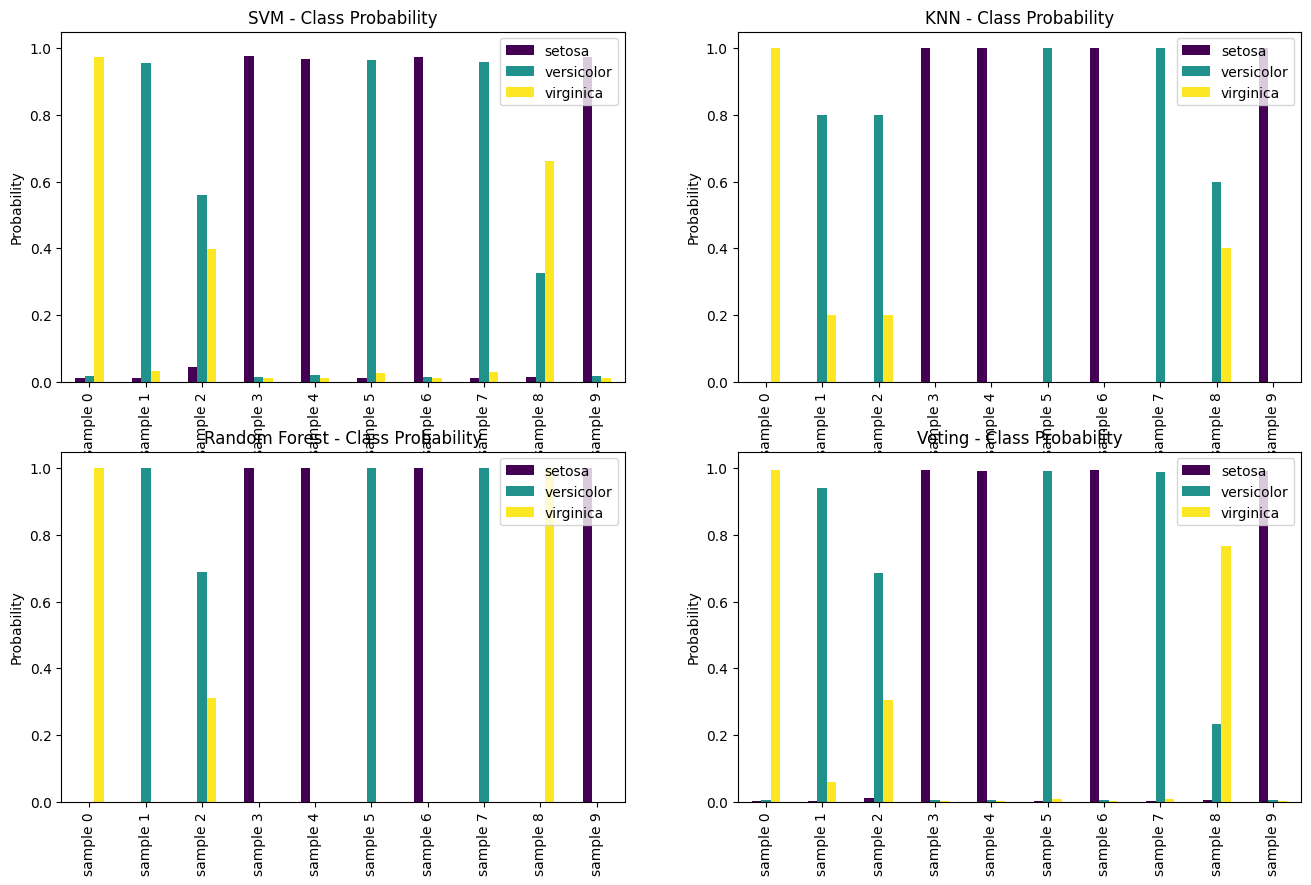

In [27]:
# 모델별 예측 확률 시각화 
idx = np.arange(10) # 10개 샘플 인덱스 생성
X_sample = X_test[idx]
y_sample = y_test[idx]

proba_svm = svm_clf.predict_proba(X_sample)
proba_knn = knn_clf.predict_proba(X_sample)
proba_rf = rf_clf.predict_proba(X_sample)
proba_vote = voting_clf.predict_proba(X_sample)

model_names = ["SVM","KNN","Random Forest","Voting"]
proba_list = [proba_svm, proba_knn, proba_rf, proba_vote]

plt.figure(figsize=(16,10))

for i, (model_name, proba) in enumerate(zip(model_names, proba_list)):
    plt.subplot(2,2,i+1)
    df_prob = pd.DataFrame(proba, columns=class_names)
    df_prob.index = [f"sample {i}" for i in range(len(df_prob))]

    df_prob.plot(kind='bar', ax=plt.gca(), colormap='viridis')
    plt.ylabel("Probability")
    plt.ylim(0,1.05)
    plt.title(f"{model_name} - Class Probability")
    plt.tight_layout

plt.show()